In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
print("Библиотеки загружены")

Библиотеки загружены


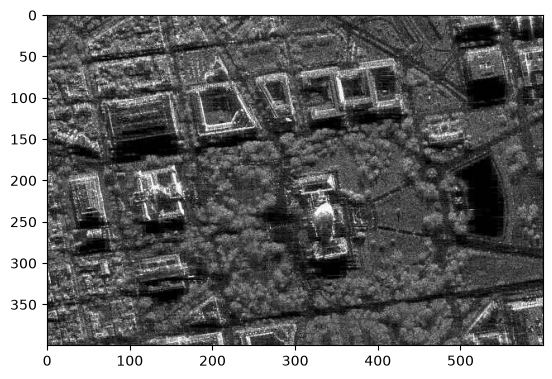

In [40]:
# 1. Загрузить изображение в оттенках серого sar_1_gray.jpg.
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')

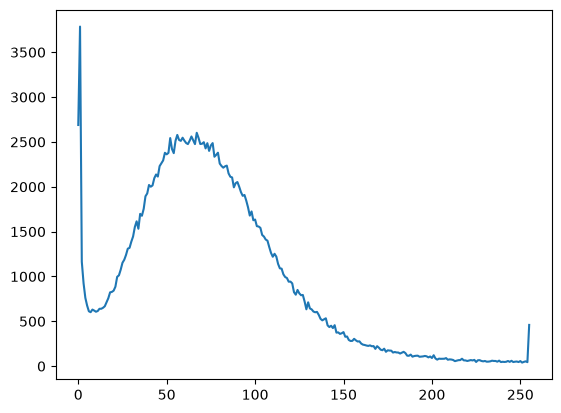

In [22]:
# 2. Построить гистограмму
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

plt.plot(hist)

Text(0.5, 1.0, 'Гамма > 1')

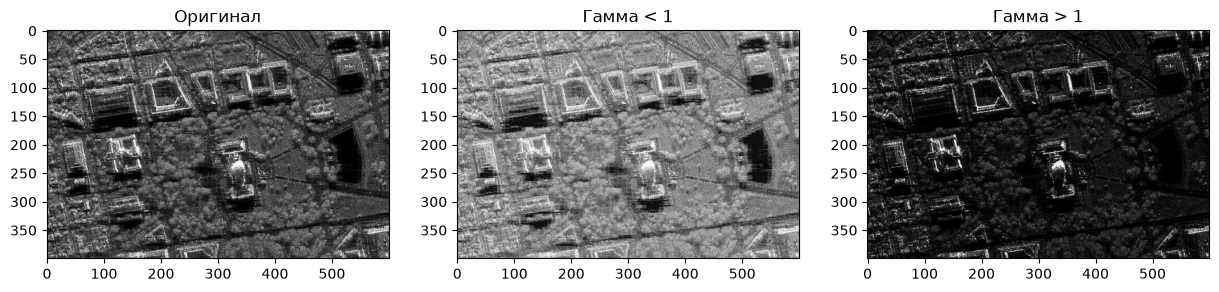

In [28]:
# 3. Гамма-коррекция
def gamma_correction(img, gamma):
    img_norm = img / 255.0
    # Возведение в степень гамма
    img_corrected = np.power(img_norm, gamma)
    return (img_corrected * 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

img_gamma_low = gamma_correction(image, 0.5)
img_gamma_high = gamma_correction(image, 2.0)

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')

plt.subplot(1, 3, 2)
plt.imshow(img_gamma_low, cmap='gray')
plt.title('Гамма < 1')

plt.subplot(1, 3, 3)
plt.imshow(img_gamma_high, cmap='gray')
plt.title('Гамма > 1')

SSIM (Гамма < 1): 0.7735745950691476
SSIM (Гамма > 1): 0.5013057984818534
MSE (Гамма < 1): 3250.429145833333
MSE (Гамма > 1): 2383.7636375


Text(0.5, 1.0, 'Разность (Гамма > 1)')

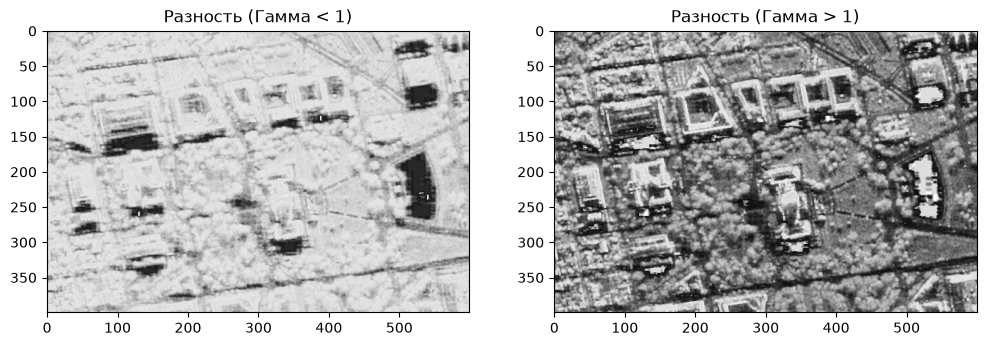

In [38]:
# 4. Сравнить исходное изображение. MSE, SSIM.
from skimage.metrics import structural_similarity, mean_squared_error

(ssim_low, diff_low) = structural_similarity(image, img_gamma_low, full=True, win_size=3)
diff_low = (diff_low * 255).astype("uint8")
print("SSIM (Гамма < 1): {}".format(ssim_low))

(ssim_high, diff_high) = structural_similarity(image, img_gamma_high, full=True, win_size=3)
diff_high = (diff_high * 255).astype("uint8")
print("SSIM (Гамма > 1): {}".format(ssim_high))

mse_low = mean_squared_error(image, img_gamma_low)
mse_high = mean_squared_error(image, img_gamma_high)
print("MSE (Гамма < 1): {}".format(mse_low))
print("MSE (Гамма > 1): {}".format(mse_high))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(diff_low, cmap='gray')
plt.title('Разность (Гамма < 1)')

plt.subplot(1, 2, 2)
plt.imshow(diff_high, cmap='gray')
plt.title('Разность (Гамма > 1)')

Text(0.5, 1.0, 'Статистическая коррекция\nmean: 123.1, std: 65.3')

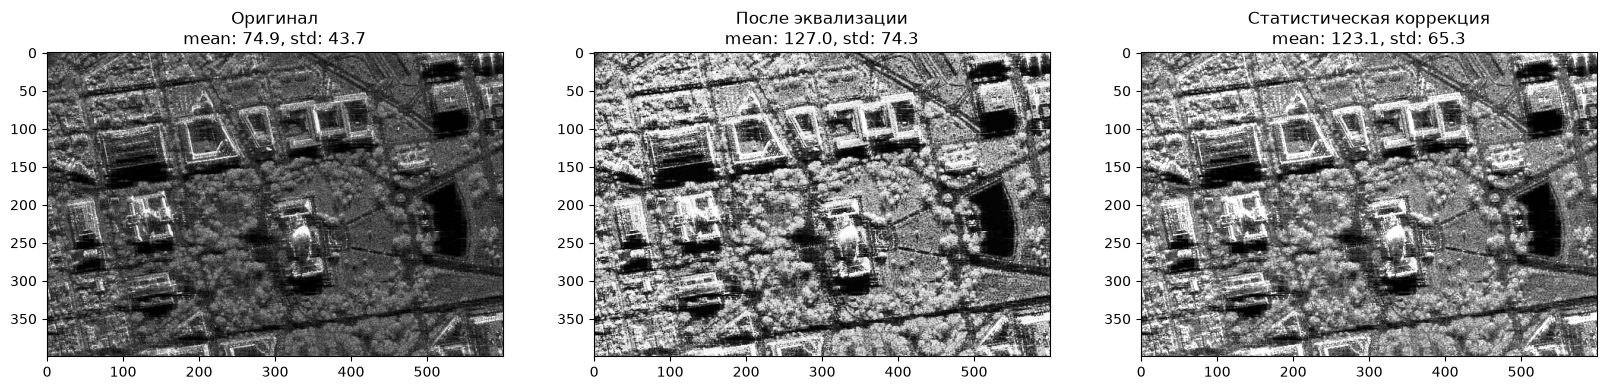

In [50]:
# 5. Статистическая цветокоррекция
mean = image.mean()
std = image.std()

eq_gray = cv2.equalizeHist(image)

mean_eq_gray = eq_gray.mean()
std_eq_gray = eq_gray.std()

corrected_img = mean_eq_gray + (image.astype(np.float32) - mean) * (std_eq_gray / std)
corrected_img = np.clip(corrected_img, 0, 255).astype(np.uint8)

mean_corr = corrected_img.mean()
std_corr = corrected_img.std()

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title(f'Оригинал\nmean: {mean:.1f}, std: {std:.1f}')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title(f'После эквализации\nmean: {mean_eq_gray:.1f}, std: {std_eq_gray:.1f}')

plt.subplot(1, 3, 3)
plt.imshow(corrected_img, cmap='gray')
plt.title(f'Статистическая коррекция\nmean: {mean_corr:.1f}, std: {std_corr:.1f}')

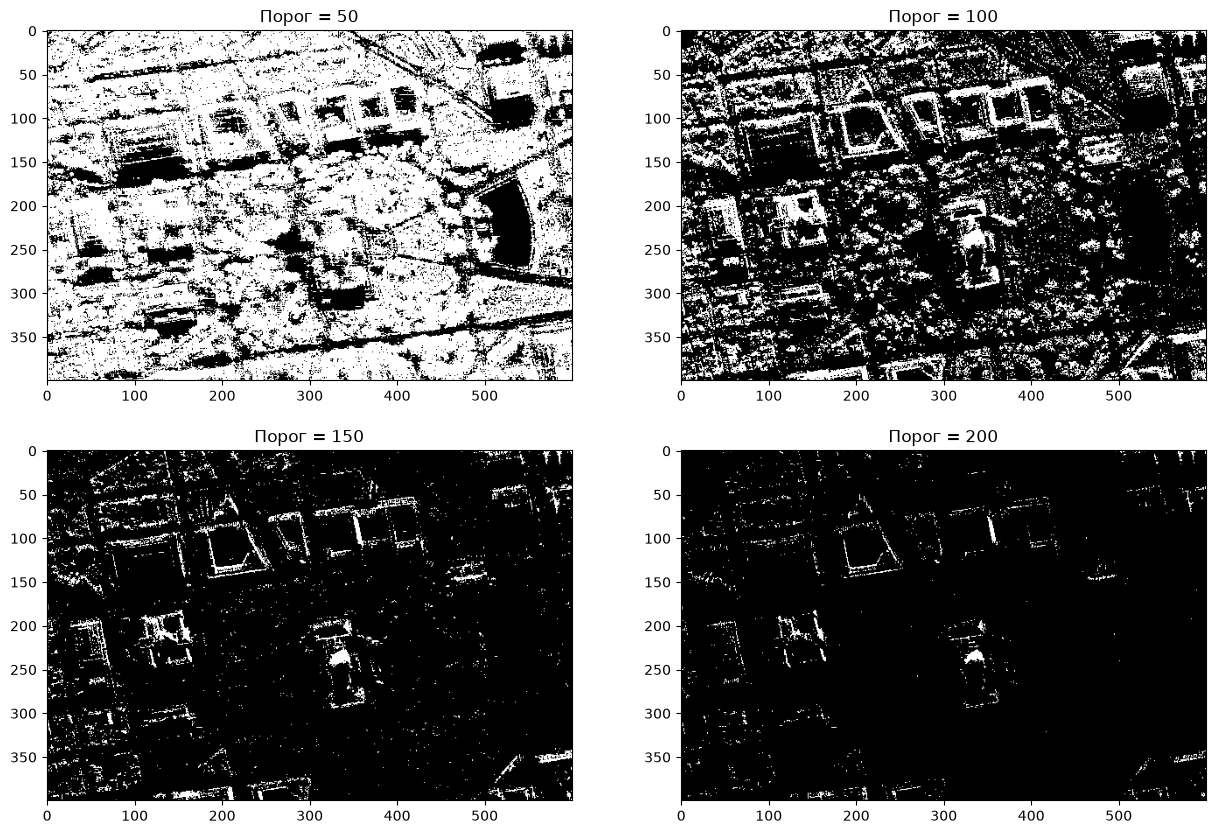

In [46]:
# 6. Пороговая фильтрация с различными параметрами
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(15, 10))

for i, thresh_val in enumerate(thresholds):
    _, thresh_img = cv2.threshold(image, thresh_val, 255, cv2.THRESH_BINARY)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'Порог = {thresh_val}')